In [2]:
# Deep learning Image Segmentation with U-Net Includes Roc Curve and Precision-Recall curve visualize

In [5]:
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

In [6]:
# try importing deep learning frameworks
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    import torch.nn.functional as F
    TORCH_AVAILABLE = True
    print("Pytorch available : ", torch.__version__)
except ImportError:
    TORCH_AVAILABLE = False
    print("Pytorch not found ")
    

Pytorch not found 


In [7]:
!pip install torch torchvision

Defaulting to user installation because normal site-packages is not writeable

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/123.0 MB 3.5 MB/s eta 0:00:35
    --------------------------------------- 1.6/123.0 MB 3.4 MB/s eta 0:00:36
    --------------------------------------- 2.4/123.0 MB 3.4 MB/s eta 0:00:36
   - -------------------------------------- 3.4/123.0 MB 3.6 MB/s eta 0:00:34
   - -------------------------------------- 3.9/123.0 MB 3.6 MB/s eta 0:00:34
   - -------------------------------------- 4.7/123.0 MB 3.6 MB/s eta 0:00:34
   - -------------------------------------- 5.5/123.0 MB 3.6 MB/s eta 0:00:33
   -- ------------------------------------- 6.3/123.0 MB 3.5 MB/s eta 0:00:33
   -- ------------------------------------- 7.1/123.0 MB 3.6 MB/s eta 0:00:33
   -- ------------------------------------- 7.9/123.0 MB 3.6 MB/s eta 0:00:32
   -- ------------------------------------- 8.4/123.0 MB 3.7 MB/s eta 0:00:32

In [15]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio


   ---------------------------------------- 0.0/122.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/122.9 MB 645.7 kB/s eta 0:03:10
   ---------------------------------------- 0.5/122.9 MB 645.7 kB/s eta 0:03:10
   ---------------------------------------- 0.8/122.9 MB 658.7 kB/s eta 0:03:06
   ---------------------------------------- 1.0/122.9 MB 762.8 kB/s eta 0:02:40
   ---------------------------------------- 1.0/122.9 MB 762.8 kB/s eta 0:02:40
    --------------------------------------- 1.6/122.9 MB 943.0 kB/s eta 0:02:09
    --------------------------------------- 1.8/122.9 MB 996.7 kB/s eta 0:02:02
    --------------------------------------- 2.4/122.9 MB 1.2 MB/s eta 0:01:45
   - --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [16]:
import sys
!{sys.executable} -m pip show torch

Name: torch
Version: 2.12.0
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: c:\users\admin\.conda\envs\segenv\lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: torchvision


In [18]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    """Two consecutive Conv-BN-ReLU blocks"""

    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    Classic U-Net for binary image segmentation
    Input : (B, C, H, W)
    Output: (B, num_classes, H, W)
    """

    def __init__(self, in_channels=1, num_classes=1,
                 features=(64, 128, 256, 512)):
        super().__init__()

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder
        ch = in_channels
        for f in features:
            self.downs.append(DoubleConv(ch, f))
            ch = f

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder
        for f in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2)
            )
            self.ups.append(
                DoubleConv(f * 2, f)
            )

        self.final = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, x):

        skip_connections = []

        # Encoder
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        # Bottleneck
        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]

        # Decoder
        for idx in range(0, len(self.ups), 2):

            x = self.ups[idx](x)

            skip = skip_connections[idx // 2]

            # Handle size mismatch
            if x.shape != skip.shape:
                x = torch.nn.functional.interpolate(
                    x,
                    size=skip.shape[2:]
                )

            x = torch.cat((skip, x), dim=1)

            x = self.ups[idx + 1](x)

        return self.final(x)


# Test
model = UNet(in_channels=1, num_classes=1)

x = torch.randn(1, 1, 256, 256)
y = model(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)
        

            
                
            

Input shape : torch.Size([1, 1, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])


In [9]:
 def forward(self, x):
            skips = []
            for down in self.downs:
                x = down(x)
                skips.append(x)
                x = self.pool(x)
 
            x = self.bottleneck(x)
            skips = skips[::-1]
 
            for i in range(0, len(self.ups), 2):
                x = self.ups[i](x)
                skip = skips[i // 2]
                if x.shape != skip.shape:
                    x = F.interpolate(x, size=skip.shape[2:])
                x = torch.cat([skip, x], dim=1)
                x = self.ups[i + 1](x)
 
            return self.final(x)

In [72]:

import numpy as np
import torch
from torch.utils.data import Dataset

class SyntheticSegDataset(Dataset):
    """
    Generates synthetic segmentation images containing
    random elliptical blobs on a noisy background.
    """

    def __init__(
        self,
        n_samples=200,
        img_size=128,
        seed=42
    ):
        super().__init__()

        rng = np.random.default_rng(seed)

        self.images = []
        self.masks = []

        for _ in range(n_samples):

            # Background noise
            img = rng.random(
                (img_size, img_size)
            ).astype(np.float32) * 0.3

            mask = np.zeros(
                (img_size, img_size),
                dtype=np.float32
            )

            # Add 1–3 ellipse objects
            n_blobs = rng.integers(1, 4)

            for _ in range(n_blobs):

                cy, cx = rng.integers(
                    20,
                    img_size - 20,
                    size=2
                )

                ry, rx = rng.integers(
                    8,
                    25,
                    size=2
                )

                y, x = np.ogrid[
                    :img_size,
                    :img_size
                ]

                ellipse = (
                    ((y - cy) / ry) ** 2 +
                    ((x - cx) / rx) ** 2
                ) <= 1

                img[ellipse] += (
                    rng.random() * 0.5 + 0.4
                )

                mask[ellipse] = 1.0

            img = np.clip(img, 0, 1)

            # Add channel dimension
            self.images.append(
                img[None, :, :]
            )

            self.masks.append(
                mask[None, :, :]
            )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = torch.tensor(
            self.images[idx],
            dtype=torch.float32
        )

        mask = torch.tensor(
            self.masks[idx],
            dtype=torch.float32
        )

        return image, mask
 
            

In [73]:
    # 4. Training Loop
    # ─────────────────────────────────────────
    def dice_loss(pred, target, smooth=1.0):
        pred   = torch.sigmoid(pred)
        num    = (pred * target).sum(dim=(2, 3))
        den    = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        return 1 - (2 * num + smooth) / (den + smooth)
 
    def combined_loss(pred, target):
        bce  = F.binary_cross_entropy_with_logits(pred, target)
        dice = dice_loss(pred, target).mean()
        return bce + dice
 
    def train_unet(epochs=10, batch_size=16, lr=1e-3, img_size=128):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"\n── Training U-Net on {device} ──")
 
        train_ds = SyntheticSegDataset(n_samples=200, img_size=img_size, seed=0)
        val_ds   = SyntheticSegDataset(n_samples=50,  img_size=img_size, seed=99)
        train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_dl   = DataLoader(val_ds,   batch_size=batch_size)
 
        model = UNet(in_channels=1, num_classes=1).to(device)
        opt   = optim.Adam(model.parameters(), lr=lr)
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
 
        history = {"train_loss": [], "val_loss": [], "val_iou": []}
 
        for ep in range(1, epochs + 1):
            # ── Train ──
            model.train()
            t_loss = 0
            for imgs, masks in train_dl:
                imgs, masks = imgs.to(device), masks.to(device)
                opt.zero_grad()
                preds = model(imgs)
                loss  = combined_loss(preds, masks)
                loss.backward()
                opt.step()
                t_loss += loss.item()
            sched.step()
            t_loss /= len(train_dl)

In [74]:
            # ── Validate ──
           # Validation Phase
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, random_split

# Your dataset object
# Replace SyntheticSegDataset with your dataset class
dataset = SyntheticSegDataset()

# Split dataset into train and validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Create DataLoaders
BATCH_SIZE = 8

train_dl = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_dl = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training samples:", len(train_ds))
print("Validation samples:", len(val_ds))

Training samples: 160
Validation samples: 40


In [75]:
print("dataset" in globals())
print("train_dl" in globals())
print("val_dl" in globals())

True
True
True


In [76]:
  # ── Collect predictions for curves ──
def collect_predictions(model, val_dl, val_ds, history):

    all_probs = []
    all_labels = []

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model.eval()

    with torch.no_grad():
        for imgs, masks in val_dl:

            imgs = imgs.to(device)

            probs = torch.sigmoid(
                model(imgs)
            ).cpu().numpy().flatten()

            all_probs.extend(probs)
            all_labels.extend(
                masks.cpu().numpy().flatten()
            )

    return (
        model,
        history,
        np.array(all_probs),
        np.array(all_labels),
        val_ds,
        device
    )

In [37]:
# 5. Simulation Fallback (no PyTorch)
# ─────────────────────────────────────────────
def simulate_predictions(n=10000, seed=7):
    """
    Simulate realistic segmentation probabilities for
    ROC / PR demo without any deep learning framework.
    """
    rng = np.random.default_rng(seed)
    labels = rng.integers(0, 2, n)
    # Model scores: foreground pixels score higher on average
    probs  = np.where(
        labels == 1,
        rng.beta(5, 2, n),   # foreground: skewed high
        rng.beta(2, 5, n),   # background: skewed low
    )
    return probs, labels

In [41]:
import sys
!{sys.executable} -m pip install scikit-learn


  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.9 MB 1.5 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/8.9 MB 1.7 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.9 MB 1.7 MB/s eta 0:00:05
   --------- ------------------------------ 2.1/8.9 MB 1.9 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/8.9 MB 2.1 MB/s eta 0:00:03
   --------------- ------------------------ 3.4/8.9 MB 2.2 MB/s eta 0:00:03
   -------------------- ------------------- 4.5/8.9 MB 2.5 MB/s eta 0:00:02
   ------------------------ --------------- 5.5/8.9 MB 2.8 MB/s eta 0:00:02
   ----------------------------- ---------- 6.6/8.9 M

In [42]:
import sklearn
print(sklearn.__version__)

1.7.2


In [77]:
# 6. Visualization



import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from matplotlib.colors import LinearSegmentedColormap

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

import torch

# ============================================================
# Color Theme
# ============================================================

PALETTE = {
    "bg": "#0d0d14",
    "panel": "#13131f",
    "border": "#2a2a3d",
    "teal": "#00e5c3",
    "purple": "#9b5de5",
    "pink": "#f72585",
    "yellow": "#f9c74f",
    "white": "#e8e8f0",
    "grey": "#555570",
}

seg_cmap = LinearSegmentedColormap.from_list(
    "seg",
    ["#0d0d14", "#00e5c3"],
    N=256
)

# ============================================================
# Styling Function
# ============================================================

def style_ax(ax, title=""):

    ax.set_facecolor(PALETTE["panel"])

    for sp in ax.spines.values():
        sp.set_edgecolor(PALETTE["border"])

    ax.tick_params(
        colors=PALETTE["grey"],
        labelsize=9
    )

    ax.xaxis.label.set_color(PALETTE["white"])
    ax.yaxis.label.set_color(PALETTE["white"])

    if title:
        ax.set_title(
            title,
            color=PALETTE["white"],
            fontsize=11,
            fontweight="bold",
            pad=8
        )

    ax.grid(
        color=PALETTE["border"],
        linewidth=0.5,
        linestyle="--",
        alpha=0.6
    )

# ============================================================
# ROC Curve
# ============================================================

def plot_roc(ax, labels, probs):

    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    ax.plot(
        fpr,
        tpr,
        color=PALETTE["teal"],
        lw=2,
        label=f"AUC = {roc_auc:.4f}"
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color=PALETTE["grey"]
    )

    ax.fill_between(
        fpr,
        tpr,
        alpha=0.10,
        color=PALETTE["teal"]
    )

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")

    style_ax(ax, "ROC Curve")

    leg = ax.legend(framealpha=0)

    for txt in leg.get_texts():
        txt.set_color(PALETTE["white"])

    return roc_auc

# ============================================================
# Precision Recall Curve
# ============================================================

def plot_pr(ax, labels, probs):

    precision, recall, _ = precision_recall_curve(
        labels,
        probs
    )

    ap = average_precision_score(
        labels,
        probs
    )

    baseline = labels.mean()

    ax.plot(
        recall,
        precision,
        color=PALETTE["purple"],
        lw=2,
        label=f"AP = {ap:.4f}"
    )

    ax.axhline(
        baseline,
        linestyle="--",
        color=PALETTE["grey"],
        label=f"Baseline = {baseline:.3f}"
    )

    ax.fill_between(
        recall,
        precision,
        alpha=0.10,
        color=PALETTE["purple"]
    )

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")

    style_ax(ax, "Precision-Recall Curve")

    leg = ax.legend(framealpha=0)

    for txt in leg.get_texts():
        txt.set_color(PALETTE["white"])

    return ap

# ============================================================
# Training History
# ============================================================

def plot_history(ax_loss, ax_iou, history):

    epochs = range(
        1,
        len(history["train_loss"]) + 1
    )

    ax_loss.plot(
        epochs,
        history["train_loss"],
        lw=2,
        color=PALETTE["pink"],
        label="Train"
    )

    ax_loss.plot(
        epochs,
        history["val_loss"],
        lw=2,
        linestyle="--",
        color=PALETTE["yellow"],
        label="Validation"
    )

    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")

    style_ax(ax_loss, "Loss Curve")

    leg = ax_loss.legend(framealpha=0)

    for txt in leg.get_texts():
        txt.set_color(PALETTE["white"])

    ax_iou.plot(
        epochs,
        history["val_iou"],
        color=PALETTE["teal"],
        lw=2,
        marker="o"
    )

    ax_iou.set_xlabel("Epoch")
    ax_iou.set_ylabel("IoU")

    style_ax(ax_iou, "Validation IoU")

# ============================================================
# Predictions
# ============================================================

def plot_predictions(axes, val_ds, model, device):

    model.eval()

    indices = [
        0,
        len(val_ds)//2,
        len(val_ds)-1
    ]

    with torch.no_grad():

        for col, idx in enumerate(indices):

            img, mask = val_ds[idx]

            pred = torch.sigmoid(
                model(
                    img.unsqueeze(0).to(device)
                )
            )

            pred = pred.squeeze().cpu().numpy()

            img_np = img.squeeze().numpy()
            mask_np = mask.squeeze().numpy()

            axes[0][col].imshow(
                img_np,
                cmap="gray"
            )

            axes[1][col].imshow(
                mask_np,
                cmap=seg_cmap
            )

            axes[2][col].imshow(
                pred,
                cmap=seg_cmap
            )

            for r in range(3):
                axes[r][col].axis("off")

# ============================================================
# Main Visualization
# ============================================================

def build_figure_torch(
    probs,
    labels,
    history,
    val_ds,
    model,
    device
):

    fig = plt.figure(
        figsize=(20, 14),
        facecolor=PALETTE["bg"]
    )

    gs_top = gridspec.GridSpec(
        2,
        2,
        figure=fig,
        left=0.06,
        right=0.98,
        top=0.95,
        bottom=0.52,
        wspace=0.32,
        hspace=0.45
    )

    gs_bot = gridspec.GridSpec(
        3,
        3,
        figure= fig,
        left=0.06,
        right=0.98,
        top=0.46,
        bottom=0.04,
        wspace=0.05,
        hspace=0.05
    )

    ax_roc = fig.add_subplot(gs_top[0, 0])
    ax_pr = fig.add_subplot(gs_top[0, 1])
    ax_loss = fig.add_subplot(gs_top[1, 0])
    ax_iou = fig.add_subplot(gs_top[1, 1])

    roc_auc = plot_roc(
        ax_roc,
        labels,
        probs
    )

    ap = plot_pr(
        ax_pr,
        labels,
        probs
    )

    plot_history(
        ax_loss,
        ax_iou,
        history
    )

    axes = [
        [fig.add_subplot(gs_bot[r, c]) for c in range(3)]
        for r in range(3)
    ]

    plot_predictions(
        axes,
        val_ds,
        model,
        device
    )

    fig.suptitle(
        "U-Net Segmentation Results",
        color=PALETTE["white"],
        fontsize=16,
        fontweight="bold"
    )

    plt.savefig(
        "unet_segmentation_results.png",
        dpi=150,
        bbox_inches="tight",
        facecolor=PALETTE["bg"]
    )

    plt.show()

    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Average Precision: {ap:.4f}")



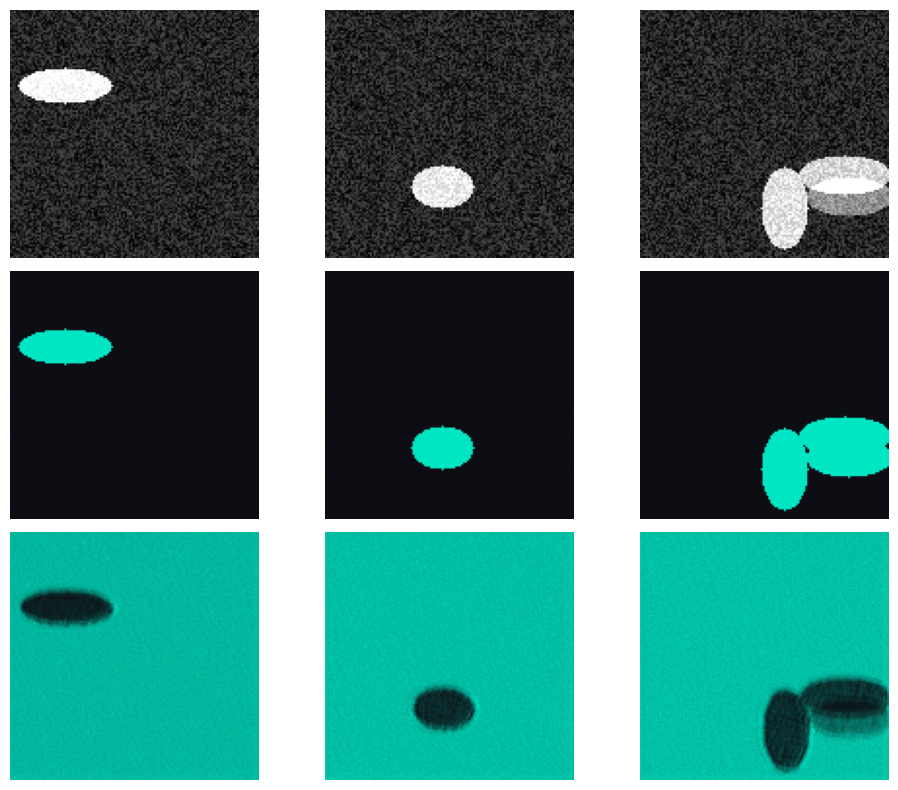

In [78]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 10))

gs_bot = gridspec.GridSpec(
    3, 3,
    figure=fig,
    wspace=0.05,
    hspace=0.05
)
# Sample predictions grid
pred_axes = []

for r in range(3):
    row = []

    for c in range(3):
        ax = fig.add_subplot(gs_bot[r, c])
        ax.set_facecolor(PALETTE["panel"])
        row.append(ax)

    pred_axes.append(row)

plot_predictions(
    pred_axes,
    val_ds,
    model,
    device
)

plt.show()

In [79]:
# Column headers
for c, lbl in enumerate(
    ["Sample A", "Sample B", "Sample C"]
):
    pred_axes[0][c].set_title(
        lbl,
        color=PALETTE["grey"],
        fontsize=9,
        pad=4
    )

fig.suptitle(
    "U-Net Image Segmentation – Full Evaluation Dashboard",
    color=PALETTE["white"],
    fontsize=15,
    fontweight="bold"
)

# Save in current notebook folder
out = "segmentation_dashboard.png"

plt.savefig(
    out,
    dpi=150,
    bbox_inches="tight",
    facecolor=PALETTE["bg"]
)

print(f"\nSaved → {out}")

if "history" in globals():
    print(
        f"Final Val IoU : "
        f"{history['val_iou'][-1]:.4f}"
    )

if "roc_auc" in globals():
    print(f"ROC AUC       : {roc_auc:.4f}")

if "ap" in globals():
    print(f"Avg Precision : {ap:.4f}")

plt.show()


Saved → segmentation_dashboard.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# ─────────────────────────────────────────────
# 7. Main
# ============================================================
# MAIN EXECUTION

# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from torch.utils.data import Dataset, DataLoader, random_split

try:
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False


def check_requirements():
    required_functions = [
        "train_unet",
        "build_figure_torch"
    ]

    missing = []

    for fn in required_functions:
        if fn not in globals():
            missing.append(fn)

    if missing:
        print("\nMissing functions:")
        for fn in missing:
            print(" -", fn)
        return False

    return True


if __name__ == "__main__":

    print("=" * 60)
    print("U-NET IMAGE SEGMENTATION")
    print("=" * 60)

    if not TORCH_AVAILABLE:
        print("\nPyTorch is not available.")
        raise SystemExit

    if not check_requirements():
        raise SystemExit

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    print(f"\nUsing device: {device}")

    try:

        model, history, probs, labels, val_ds, device = train_unet(
            epochs=15,
            batch_size=16,
            lr=1e-3,
            img_size=128
        )

        print("\nTraining completed successfully.")

        build_figure_torch(
            probs,
            labels,
            history,
            val_ds,
            model,
            device
        )

        print("\nEvaluation dashboard generated.")

    except Exception as e:

        print("\nTraining failed.")
        print("Error:", e)

    print("\nDone.")

U-NET IMAGE SEGMENTATION

Using device: cpu

── Training U-Net on cpu ──
